# Fitting a power-law PDF to the density diagnostic trend

This is an extension of the `density_diagnostic_trends` notebook, with the aim to

1. Perform a least squares fit of the model to the data
2. Calculate the credibility regions of the model parameters via MCMC

Both can be handled by the `lmfit` library. 

All the classes and functions from `density_diagnostic_trends.ipynb` have been extracted into the `ddtrends.py` module. 

In [1]:
import numpy as np
from astropy.table import Table
from matplotlib import pyplot as plt
import seaborn as sns
import corner
from lmfit import Model
import ddtrends as ddt

In [2]:
sns.set_context("notebook")

## Empirical density trend for Orion

The following data was extracted from the Eduardo draft paper Figure 1, using ChatGPT

In [3]:
density_diagnostic_points = [
    # (diagnostic, log_nM, log_nobs, independent_subset)
    ("[S II] 6717/6731", 3.06, 2.309, True),
    ("[O II] 3727/3729", 3.16, 2.540, True),
    ("[Fe III] 4986/4881", 3.74, 2.685, True),
    ("[Fe III] 4658/4986", 3.84, 2.395, True),
    ("[Cl III] 5538/5518", 3.99, 3.070, True),
    ("[Fe III] 4986/4702", 4.04, 2.479, False),
    ("[S II] 4070/6717", 4.64, 2.593, False),
    ("[O II] 7320/3729", 4.69, 2.868, False),
    ("[S II] 4070/(6717+6731)", 4.85, 2.757, True),
    ("[S II] (4070+4075)/(6717+6731)", 4.91, 2.979, False),
    ("[O II] 7320/(3727+3729)", 5.03, 2.942, True),
    ("[O II] 7320/3727", 5.10, 3.127, False),
    ("[Fe III] 4702/4881", 6.19, 3.696, True),
    ("[Fe II] 8617/7155", 6.31, 3.333, True),
    ("[Fe III] 4658/4881", 6.36, 3.608, False),
    ("[Fe III] 4658/4702", 6.90, 3.457, False),
]

Convert to an `astropy.Table` for ease of management

In [4]:
ori_tab = Table(
    rows=density_diagnostic_points,
    names=[
        "ratio",
        "log10(n_M)",
        "log10(n_obs)",
        "independent?",
    ],
)

Display the full data table

In [5]:
ori_tab

ratio,log10(n_M),log10(n_obs),independent?
str30,float64,float64,bool
[S II] 6717/6731,3.06,2.309,True
[O II] 3727/3729,3.16,2.54,True
[Fe III] 4986/4881,3.74,2.685,True
[Fe III] 4658/4986,3.84,2.395,True
[Cl III] 5538/5518,3.99,3.07,True
[Fe III] 4986/4702,4.04,2.479,False
[S II] 4070/6717,4.64,2.593,False
[O II] 7320/3729,4.69,2.868,False
[S II] 4070/(6717+6731),4.85,2.757,True


Display the subset of points with ratios that are algebraically independent

In [6]:
subset = ori_tab["independent?"]
ori_tab[subset]

ratio,log10(n_M),log10(n_obs),independent?
str30,float64,float64,bool
[S II] 6717/6731,3.06,2.309,True
[O II] 3727/3729,3.16,2.54,True
[Fe III] 4986/4881,3.74,2.685,True
[Fe III] 4658/4986,3.84,2.395,True
[Cl III] 5538/5518,3.99,3.07,True
[S II] 4070/(6717+6731),4.85,2.757,True
[O II] 7320/(3727+3729),5.03,2.942,True
[Fe III] 4702/4881,6.19,3.696,True
[Fe II] 8617/7155,6.31,3.333,True


Plot the data with the linear trend fit and 95% confidence interval

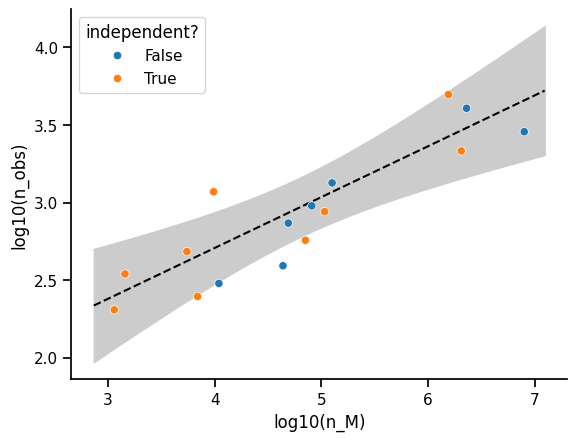

In [7]:
ax = sns.scatterplot(ori_tab.to_pandas(), x="log10(n_M)", y="log10(n_obs)", hue="independent?")
xx = np.linspace(*ax.get_xlim())
ax.plot(xx, np.log10(ddt.n_obs_improved_fit(10**xx)), color="k", ls="dashed", zorder=0)
ax.fill_between(
    xx,
    np.log10(ddt.n_obs_improved_fit(10**xx, line_type="lower")),
    np.log10(ddt.n_obs_improved_fit(10**xx, line_type="upper")),
    color="0.8",
    zorder=-1,
)
sns.despine()

## Perform the fit to the data

Unlike in the previous notebook, we will work exclusively in log-log space.

First make convenient vectors of the data to be fitted.

In [8]:
xdata = ori_tab[subset]["log10(n_M)"].data
ydata = ori_tab[subset]["log10(n_obs)"].data
xdata, ydata

(array([3.06, 3.16, 3.74, 3.84, 3.99, 4.85, 5.03, 6.19, 6.31]),
 array([2.309, 2.54 , 2.685, 2.395, 3.07 , 2.757, 2.942, 3.696, 3.333]))

Define a `lmfit.Model` object for the power-law PDF.

Instead of including the upper density bound `log_n1` as a parameter, we instead use the width of the interval `log_width = log_n1 - log_n0`, which is the same as $\log_{10} n_\max / n_\min$. The reason is to allow us to enforce `log_n1 > log_n0`

***TODO*** *We still need to justify the variation of $\delta$ with $n_\mathcal{M}$*


In [9]:
def plaw_model(x, m, log_n0, log_width):
    """
    Model function for log10_n_obs(log10_n_M) with parameters (m, log_n0, log_width)

    The upper bound on density is log_n1 = log_n0 + log_width

    We do not use log_n1 directly as a parameter since we want to make sure
    it is always greater than the lower bound. Also, it is very poorly constrained by the data

    Suitable for use with lmfit.Model
    """

    # Set up diagnostic line ratio parameters
    nM = 10 ** x
    # Vary with nM = 1e3 -> 1e7 as delta = 2 -> 200
    delta = 2.0 * np.sqrt(nM / 1e3)

    # Set up power-law PDF
    log_n1 = log_n0 + log_width
    pdf = ddt.PowerLawPDF(m, 10 ** log_n0, 10 ** log_n1)

    # Find observed density using the vectorized function
    n_obs = ddt.n_app_from_nM(nM, pdf, delta=delta)

    return np.log10(n_obs)
    

pmodel = Model(plaw_model)

In [10]:
pmodel.param_names, pmodel.independent_vars

(['m', 'log_n0', 'log_width'], ['x'])

Set initial values for parameters. We restrict the values, but over a broad range of:
* $m = [-3.0, +0.5]$
* $\log_{10} n_0 = [-3.0, +3.5]$
* $\log_{10} n_1 / n_0 = [+0.1, +8.0]$

This is only important for the upper limit, which otherwise tends to go ridiculously high. 

In [11]:
params = pmodel.make_params(
    m=dict(value=-0.5, min=-3, max=0.5),
    log_n0=dict(value=-1.0, min=-3, max=3.5),
    # log_width=dict(value=5.0, min=0.1, max=12),
    log_width=dict(value=5.0, min=0.1, max=8),
)
params

name,value,initial value,min,max,vary
m,-0.50000000,-0.5,-3.00000000,0.50000000,True
log_n0,-1.00000000,-1.0,-3.00000000,3.50000000,True
log_width,5.00000000,5.0,0.10000000,8.00000000,True


Fit model to the data

In [12]:
sig_y = 0.25 * np.ones_like(ydata)

In [13]:
result = pmodel.fit(ydata, params, x=xdata, weights=1 / sig_y)

In [14]:
from IPython.display import Markdown, display

def show_fit_md(result, heading="Fit result", level=4):
    hashes = "#" * level
    report = result.fit_report()
    display(Markdown(f"{hashes} {heading}\n\n```text\n{report}\n```"))



In [15]:
show_fit_md(result, heading="LMfit result", level=3)

### LMfit result

```text
[[Model]]
    Model(plaw_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 47
    # data points      = 9
    # variables        = 3
    chi-square         = 6.21149510
    reduced chi-square = 1.03524918
    Akaike info crit   = 2.66259342
    Bayesian info crit = 3.25426715
    R-squared          = 0.76283172
[[Variables]]
    m:         -1.38652009 +/- 0.20408782 (14.72%) (init = -0.5)
    log_n0:     1.62453280 +/- 0.46526320 (28.64%) (init = -1)
    log_width:  8.00000000 +/- 4458.68336 (55733.54%) (init = 5)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, log_n0)         = -0.9154
    C(m, log_width)      = -0.8159
    C(log_n0, log_width) = +0.6535
```

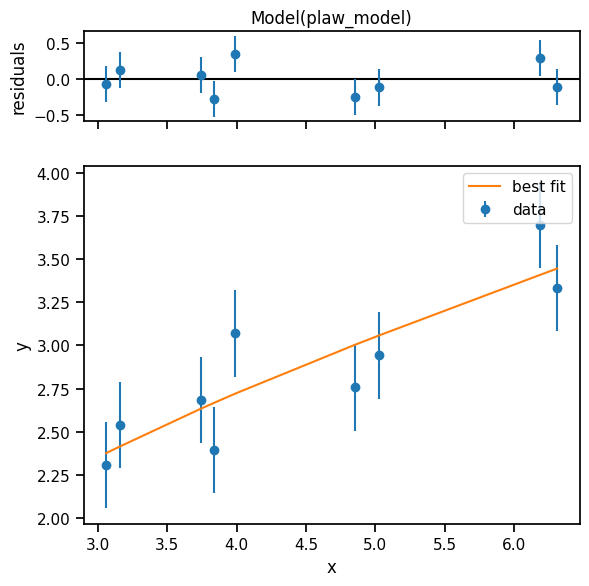

In [16]:
result.plot();

So the best-fit values of power-law slope $m = -1.4 \pm 0.2$ and lower density bound $\log_{10} n_0 = 1.6 \pm 0.5$ are very similar to the values found by hand in the previous notebook.

However, the upper density bound gets stuck at the highest allowed value $\log_{10} (n_1 / n_0) = 11.0$ with a nonsensical error estimate. *This gets fixed below in the MCMC fits*

## Find credibile bounds on PDF parameters with MCMC

Use the `emcee` method, starting from the parameters of the previous fit.

In [17]:
mcmc_params = result.params.copy()
#mcmc_params.add("__lnsigma", value=np.log(0.1), min=np.log(0.001), max=np.log(1))

The important thing here is to fix the estimated scatter of the data points a priori. This is set via the `weights=1 / sig_y` parameter to the fit. I use $\sigma_y = 0.25~\text{dex}$, which gives a reduced $\chi^2$ of about unity.

If we do not do this, then the mcmc walkers spend all their time investigating the possibility that the scatter might be larger, which would mean the model would be more poorly constrained, and the resulting posteriors look a real mess.

In [18]:
emcee_kws = dict(
    steps=10_000,
    burn=1000,
    thin=1,
    seed=2026_06_09,
    progress=True,
    workers=1,
)

I find 10,000 steps is required to avoid the autocorrelation warning. 

I am leaving it single-threaded for now, since multiprocessing does not play nicely with a function defined in a notebook cell. I would have to move `plaw_model()` to a python file in order to use multiple workers. It takes a bit less than a minute to run on my laptop.

In [19]:
mcmc_result = pmodel.fit(
    data=ydata,
    x=xdata,
    weights=1 / sig_y,
    params=mcmc_params,
    method="emcee",
    fit_kws=emcee_kws,
) 

  0%|          | 0/10000 [00:00<?, ?it/s]/Users/will/Dropbox/hii-density-distribution/.venv/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [00:54<00:00, 183.29it/s]


In [20]:
show_fit_md(mcmc_result, heading="MCMC result", level=3)

### MCMC result

```text
[[Model]]
    Model(plaw_model)
[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 1000000
    # data points      = 9
    # variables        = 3
    chi-square         = 6.62126204
    reduced chi-square = 1.10354367
    Akaike info crit   = 3.23755274
    Bayesian info crit = 3.82922647
    R-squared          = 0.74718593
[[Variables]]
    m:         -1.31837243 +/- 0.24030893 (18.23%) (init = -1.38652)
    log_n0:     1.47252634 +/- 0.83896256 (56.97%) (init = 1.624533)
    log_width:  5.31451917 +/- 1.61646168 (30.42%) (init = 8)
[[Correlations]] (unreported correlations are < 0.100)
    C(m, log_n0)         = -0.8276
    C(log_n0, log_width) = -0.1290
    C(m, log_width)      = -0.1164
```

### Compare LMfit versus MCMC

In [21]:
result.params

name,value,standard error,relative error,initial value,min,max,vary
m,-1.38652009,0.20408782,(14.72%),-0.5,-3.00000000,0.50000000,True
log_n0,1.62453280,0.46526320,(28.64%),-1.0,-3.00000000,3.50000000,True
log_width,8.00000000,4458.68336,(55733.54%),5.0,0.10000000,8.00000000,True


In [22]:
mcmc_result.params

name,value,standard error,relative error,initial value,min,max,vary
m,-1.31837243,0.24030893,(18.23%),-1.3865200863713567,-3.00000000,0.50000000,True
log_n0,1.47252634,0.83896256,(56.97%),1.6245327979334538,-3.00000000,3.50000000,True
log_width,5.31451917,1.61646168,(30.42%),7.999999997952536,0.10000000,8.00000000,True


The best value and uncertainty on $m$ are nearly identical. For the lower density bound, the value is the same, but the uncertainty is a bit higher with MCMC because it has found an extended tail towards low values (see below). 

In [23]:
fc = mcmc_result.flatchain
print("quantile", *mcmc_result.var_names)
for q in [0.05, 0.16, 0.50, 0.84, 0.95]:
    print(q, *[f"{fc[p].quantile(q):.2f}" for p in mcmc_result.var_names] )

quantile m log_n0 log_width
0.05 -1.63 -1.66 3.09
0.16 -1.50 0.25 3.80
0.5 -1.32 1.47 5.31
0.84 -1.02 1.91 7.02
0.95 -0.87 2.12 7.67


In [24]:
posterior_samples = mcmc_result.flatchain.sample(n=100, random_state=1972_01_30)

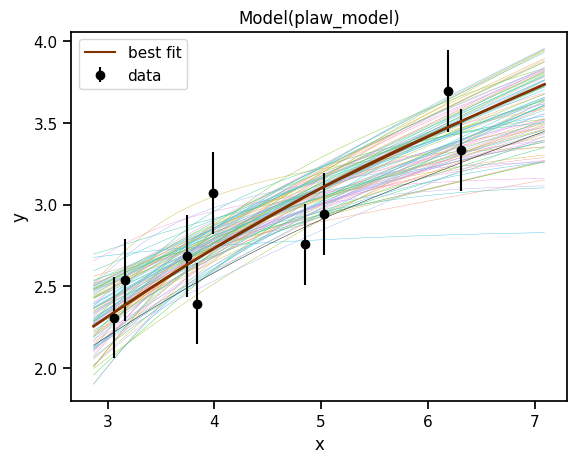

In [25]:
# Pastel colored lines for the posterior sample
my_palette = sns.husl_palette(n_colors=101, s=0.9, l=0.75, h=0.8)
# Reserve first two colormap entries for data and best fit, with darker colors
my_palette[0] = (0, 0, 0)
my_palette[1] = (0.5, 0.2, 0)
with my_palette:
    g = mcmc_result.plot_fit()
    for d in posterior_samples.to_dict(orient="records"):
        g.plot(xx, mcmc_result.eval(x=xx, **d), alpha=1, lw=0.3, zorder=-1)
    # Replot the fit line over the full range, making sure to use the same color
    g.plot(xx, mcmc_result.eval(x=xx), lw=2, color=sns.color_palette()[1])

### Corner plot of MCMC result

The first versions of this were looking really rough, but after a lot of work I have managed to get it to look pretty

In [26]:
red_cmap = sns.color_palette("light:salmon", n_colors=4)
red_cmap[0] = (1, 1, 1)
red_cmap

[(1, 1, 1),
 (0.9612129813824833, 0.7948829207532905, 0.7760548152727244),
 (0.9708025691226142, 0.6484218525335079, 0.6115568194010681),
 (0.9803921568627451, 0.5019607843137255, 0.4470588235294118)]

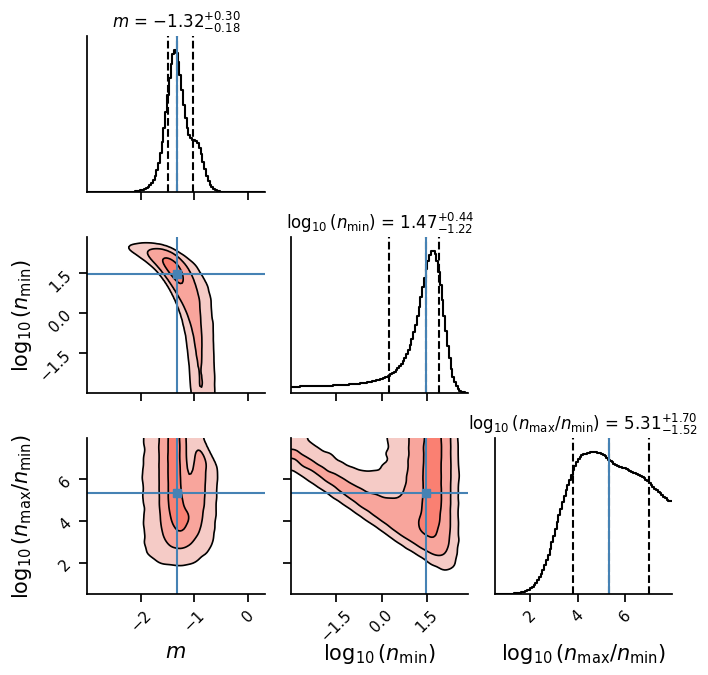

In [27]:
samples = mcmc_result.flatchain[["m", "log_n0", "log_width"]]
labels = [
    r"$m$",
    r"$\log_{10} (n_\min)$",
    r"$\log_{10}(n_\max/n_\min)$",
]
fig = corner.corner(
    samples,
    labels=labels,
    truths=[
        np.median(samples["m"]),
        np.median(samples["log_n0"]),
        np.median(samples["log_width"]),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 15},
    bins=100,
    plot_datapoints=False,
    fill_contours=True,
    smooth=2,
    smooth1d=2,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    contourf_kwargs={
        # "cmap": "Reds",
        "colors": red_cmap,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)
sns.despine()
fig.set_size_inches(7.0, 7.0)
fig.tight_layout()

Contours show the 1, 2, and 3-sigma boundaries of the pairwise posterior distributions of model parameters. The blue point and lines show the median values. The dashed lines show the (16, 84)% quantiles ($\pm 1 \sigma$) of the marginal distributions. 

### Alternative corner plot that directly shows upper bound $\log_{10} n_\max$

In [28]:
samples["log_n1"] = samples["log_n0"] + samples["log_width"]
samples

,m,log_n0,log_width,log_n1
0,-1.207231,1.033609,6.804251,7.837860
1,-1.119199,0.272352,4.890934,5.163286
2,-0.848778,-0.455906,4.657163,4.201257
3,-0.932680,-0.411875,5.127386,4.715511
4,-1.375861,1.819149,3.634423,5.453572
...,...,...,...,...
899995,-1.344168,1.533079,4.226769,5.759848
899996,-1.407838,1.500455,6.109352,7.609808
899997,-1.210731,0.980764,4.242295,5.223059
899998,-1.570258,2.149470,7.926687,10.076157


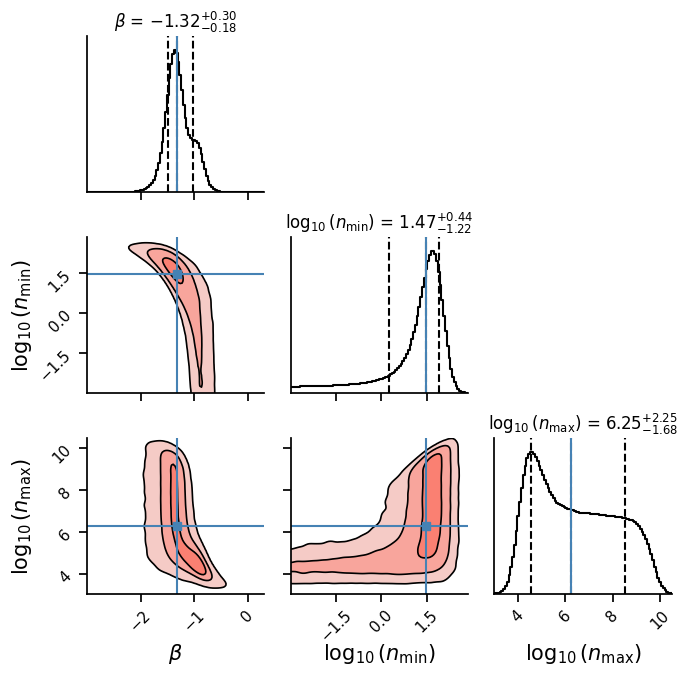

In [29]:
labels = [
    r"$\beta$",
    r"$\log_{10} (n_\min)$",
    r"$\log_{10} (n_\max)$",
]
fig = corner.corner(
    samples[["m", "log_n0", "log_n1"]],
    labels=labels,
    truths=[
        np.median(samples["m"]),
        np.median(samples["log_n0"]),
        np.median(samples["log_n1"]),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 15},
    bins=100,
    plot_datapoints=False,
    fill_contours=True,
    smooth=2,
    smooth1d=2,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    contourf_kwargs={
        # "cmap": "Reds",
        "colors": red_cmap,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)
sns.despine()
fig.set_size_inches(7.0, 7.0)
fig.tight_layout()
fig.savefig("plaw-density-distribution-mcmc-corner-uniform.pdf")

This is better because it shows more clearly the two different components of the $m$ marginal distribution:
1. Major component (about 70% of the posterior) with the following characteristics:
   * $m \approx -1.4 \pm 0.2$
   * $\log_{10}(n_\min) \approx 1.6$
   * $\log_{10}(n_\max) \ge 4$ but unconstrained upper limit to the upper bound.
2. Minor component (about 30% of the posterior) with the following characteristics:
   * $m \approx -1.0$
   * $\log_{10}(n_\min) \le 2.5$ but with unconstrained lower limit to the lower bound
   * $\log_{10}(n_\max) \approx 4.5$

We can try and separate out these two populations. See the section below. Thsi gives slightly different values for the best fits if we fix the slope at $-1.4$ and $-1.0$. We could do a better job by fitting a sum of two Gaussians to the marginal posterior $m$ distribution, but that hardly seems worth it.

## Calculate chacteristic densities for the fitted distributions

The most important of these is the RMS density, since that is needed for the Strömgren condition.

### TODO

In [30]:
pdf = ddt.PowerLawPDF(-1.3, 10**1.5, 10**6.3)
pdf.nrms()

NameError: name 'sef' is not defined

## Using a physically motivated prior based on the Strömgren condition

Since I had complained that the lognormal PDF might violate this condition, it would be hypocritical of me not to apply it here.

The idea is to use the observed Strömgren radius, together with an estimate of the effective ionizing luminosity, $(1 - f_\text{esc})\, (1 - f_\text{d})\, Q_{49}$, to estimate the RMS density, $\langle n^2 \rangle^{1/2}$

$$
\langle n \rangle_V = \frac{m-1}{m}\frac{n_1^m-n_0^m}{n_1^{m-1}-n_0^{m-1}}
$$
$$
\langle n^2 \rangle_V = \frac{m-1}{m+1} \ \frac{n_1^{m+1}-n_0^{m+1}}{n_1^{m-1}-n_0^{m-1}}
$$

### TODO

## Find the posterior distribution of emission fractions above different density thresholds

We want to find the fraction of the total emission from gas with density above a certain threshold (e.g., 1e6 pcc).  This is a determinate funtion of the power law parameters. Therefore, we can calculate it for each sample in the posterior `flatchain` samples, and then calculate the histogram.

## Two-parameter fits with fixed $m = -1.4$ and $m = -1.0$

Summary of results (see the "Compare results and corner plots" section)
| Posterior component | $m$ | $\log_{10} n_\min$ | $\log_{10} n_\max$ | $\chi^2 / \nu$ |
| :-- | :-- |:-- | :-- | :-- |
| Major | $-1.4$  | $1.7 \pm 0.2$ | $ 7.4 \pm 1.5$ |  $0.90$|
| Minor | $-1.0$  | $0.0 \pm 1.0$ | $ 4.7 \pm 0.4$ | $1.14$ |

In [ ]:
params_major = result.params.copy()
params_major["m"].vary = False
params_major["m"].value = -1.4
params_major

In [ ]:
result_major = pmodel.fit(ydata, params_major, x=xdata, weights=1 / sig_y)

In [ ]:
params_minor = result.params.copy()
params_minor["m"].vary = False
params_minor["m"].value = -0.999
result_minor = pmodel.fit(ydata, params_minor, x=xdata, weights=1 / sig_y)

In [ ]:
show_fit_md(result_major, heading="LMfit with fixed $m = -1.4$ ", level=3)

In [ ]:
result_major.plot();

In [ ]:
show_fit_md(result_minor, heading="LMfit with fixed $m = -1.0$", level=3)

In [ ]:
result_minor.plot();

In [ ]:
mcmc_result_major = pmodel.fit(
    data=ydata,
    x=xdata,
    weights=1 / sig_y,
    params=params_major,
    method="emcee",
    fit_kws=emcee_kws,
) 

In [ ]:
show_fit_md(mcmc_result_major, heading="MCMC  with fixed $m = -1.4$ ", level=3)

In [ ]:
mcmc_result_minor = pmodel.fit(
    data=ydata,
    x=xdata,
    weights=1 / sig_y,
    params=params_minor,
    method="emcee",
    fit_kws=emcee_kws,
) 

In [ ]:
show_fit_md(mcmc_result_minor, heading="MCMC  with fixed $m = -1.0$ ", level=3)

### Compare results and corner plots

In [ ]:
mcmc_result_major.params

In [ ]:
mcmc_result_minor.params

In [ ]:
samples_major = mcmc_result_major.flatchain[["log_n0", "log_width"]]
samples_major["log_n1"] = samples_major["log_n0"] + samples_major["log_width"]

In [ ]:
labels = [
    r"$\log_{10} (n_\min)$",
    r"$\log_{10} (n_\max)$",
]
fig = corner.corner(
    samples_major[["log_n0", "log_n1"]],
    labels=labels,
    truths=[
        np.median(samples_major["log_n0"]),
        np.median(samples_major["log_n1"]),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 15},
    bins=100,
    plot_datapoints=False,
    fill_contours=True,
    smooth=2,
    smooth1d=2,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    contourf_kwargs={
        # "cmap": "Reds",
        "colors": red_cmap,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)
sns.despine()
fig.set_size_inches(7.0, 7.0)
fig.suptitle("Power law with fixed slope, $m = -1.4$")
fig.tight_layout()

In [ ]:
samples_minor = mcmc_result_minor.flatchain[["log_n0", "log_width"]]
samples_minor["log_n1"] = samples_minor["log_n0"] + samples_minor["log_width"]

In [ ]:
labels = [
    r"$\log_{10} (n_\min)$",
    r"$\log_{10} (n_\max)$",
]
fig = corner.corner(
    samples_minor[["log_n0", "log_n1"]],
    labels=labels,
    truths=[
        np.median(samples_minor["log_n0"]),
        np.median(samples_minor["log_n1"]),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 15},
    bins=100,
    plot_datapoints=False,
    fill_contours=True,
    smooth=2,
    smooth1d=2,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    contourf_kwargs={
        # "cmap": "Reds",
        "colors": red_cmap,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)
sns.despine()
fig.set_size_inches(7.0, 7.0)
fig.tight_layout()